# Zadanie 1. Segmentacja klientów banku - Grupowanie hierarchiczne


> **Raport końcowy** znajduje się na końcu notebooka.

## Import bibliotek

In [277]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

import warnings
warnings.filterwarnings('ignore')
sns.set_theme()

## Wczytanie danych

In [278]:
df = pd.read_csv('bank.csv')
print('Wymiar:', df.shape)
df.head()

Wymiar: (10127, 21)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


## Eksploracja danych

In [279]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  str    
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  str    
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  str    
 6   Marital_Status            10127 non-null  str    
 7   Income_Category           10127 non-null  str    
 8   Card_Category             10127 non-null  str    
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_Revolving_B

In [280]:
print('Liczba braków:')
df.isnull().sum()

Liczba braków:


CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [281]:
# Sprawdzenie duplikatów
print('Liczba zdublowanych wierszy:', df.duplicated().sum())

Liczba zdublowanych wierszy: 0


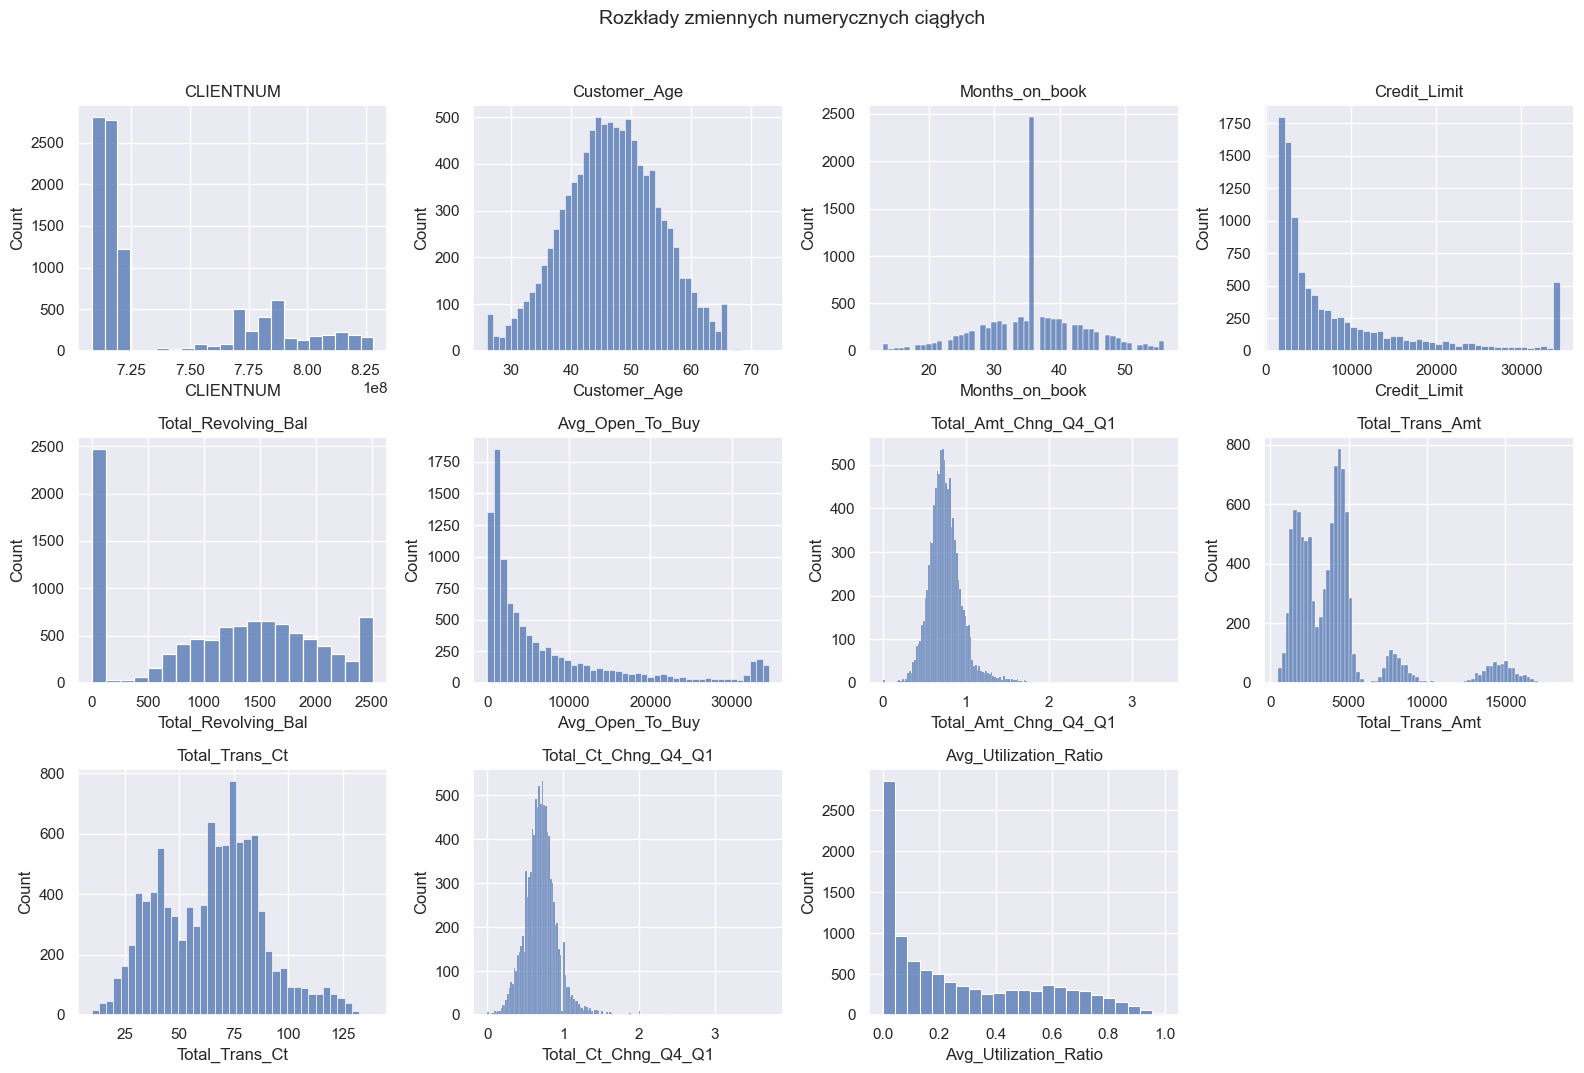

In [282]:
# Histogramy zmiennych ciągłych
discrete_cols = ['Dependent_count', 'Total_Relationship_Count',
                 'Months_Inactive_12_mon', 'Contacts_Count_12_mon']
num_cols = df.select_dtypes(include=np.number).columns.tolist()
continuous_cols = [c for c in num_cols if c not in discrete_cols]

n = len(continuous_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
for ax, col in zip(axes.flatten(), continuous_cols):
    sns.histplot(df[col], ax=ax)
    ax.set_title(col)
for ax in axes.flatten()[n:]:
    ax.axis('off')
fig.suptitle('Rozkłady zmiennych numerycznych ciągłych', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

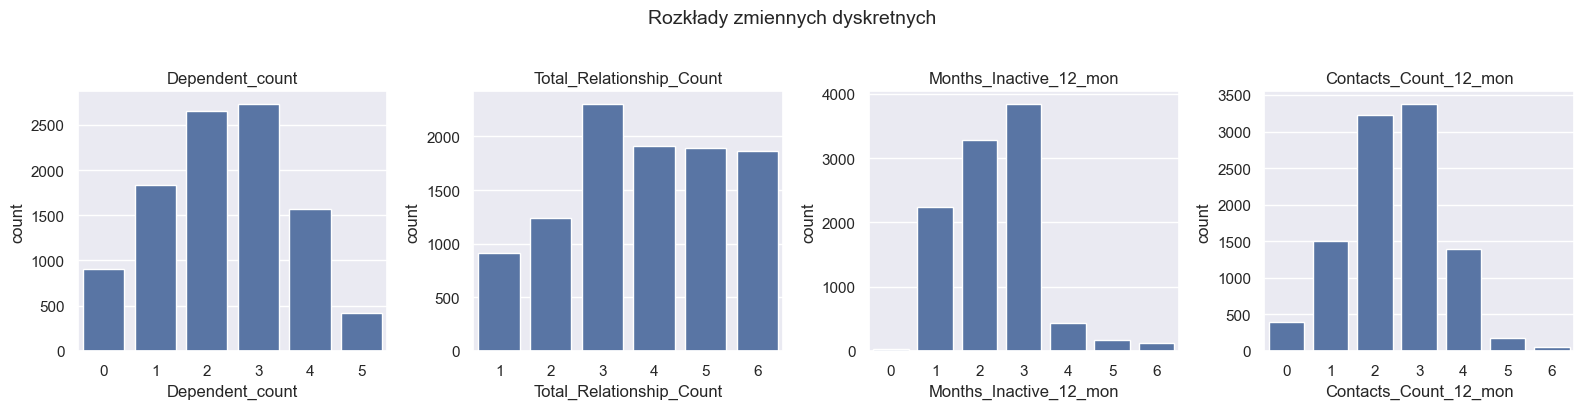

In [283]:
# Wykresy słupkowe zmiennych dyskretnych (porządkowych o małym zakresie wartości)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, discrete_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
fig.suptitle('Rozkłady zmiennych dyskretnych', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

#### Na wykresach widać:
- `Credit_Limit` i `Avg_Open_To_Buy` mają silnie prawostronny rozkład z długim ogonem, źle wpłyną na mój model, jeśli pozostawię je bez zmian, dlatego zastosuje `np.log1p`.
- `Total_Revolving_Bal` i `Avg_Utilization_Ratio` mają duży wzrost przy 0, oznacza to klientów bez zadłużenia odnawialnego.

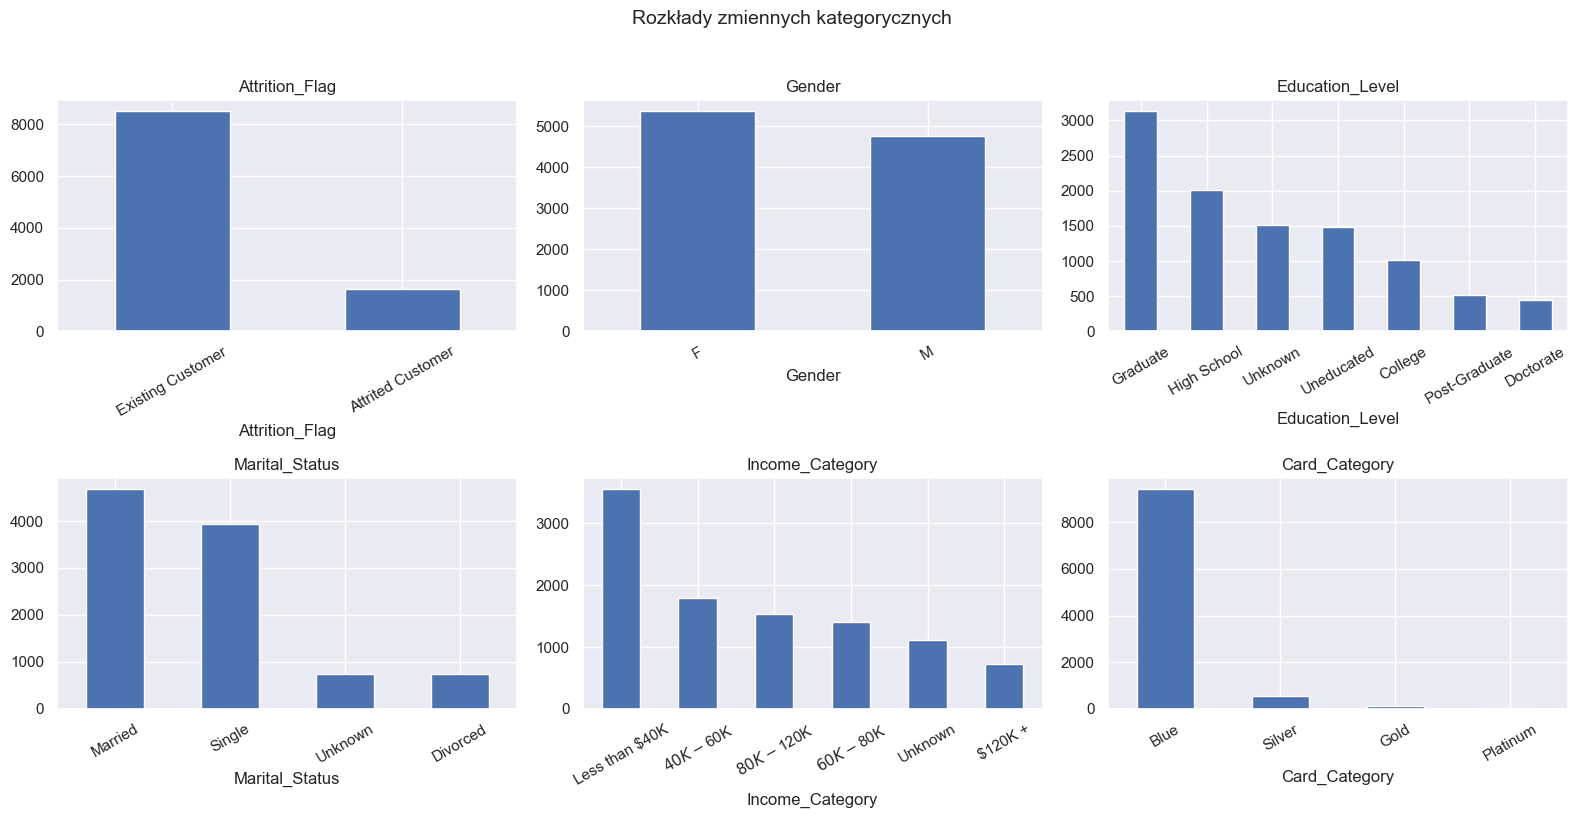

In [284]:
# Wykresy słupkowe zmiennych kategorycznych
cat_cols = df.select_dtypes(include='object').columns.tolist()
n_cat = len(cat_cols)
ncols = 3
nrows = int(np.ceil(n_cat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
for ax, col in zip(axes.flatten(), cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, edgecolor='white')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
for ax in axes.flatten()[n_cat:]:
    ax.axis('off')
fig.suptitle('Rozkłady zmiennych kategorycznych', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

#### Na wykresach widać:
- `Attrition_Flag` - ~84% aktywnych vs ~16% churned, zapamiętam jako etykietę do oceny wyników.
- `Card_Category` - ~90% klientów ma kartę Blue, Silver/Gold/Platinum to margines, zmienna ma bardzo niską wariancję, przez co może wprowadzać szum.
- `Gender` - niemal równy podział, nie będzie silnym czynnikiem różnicującym.

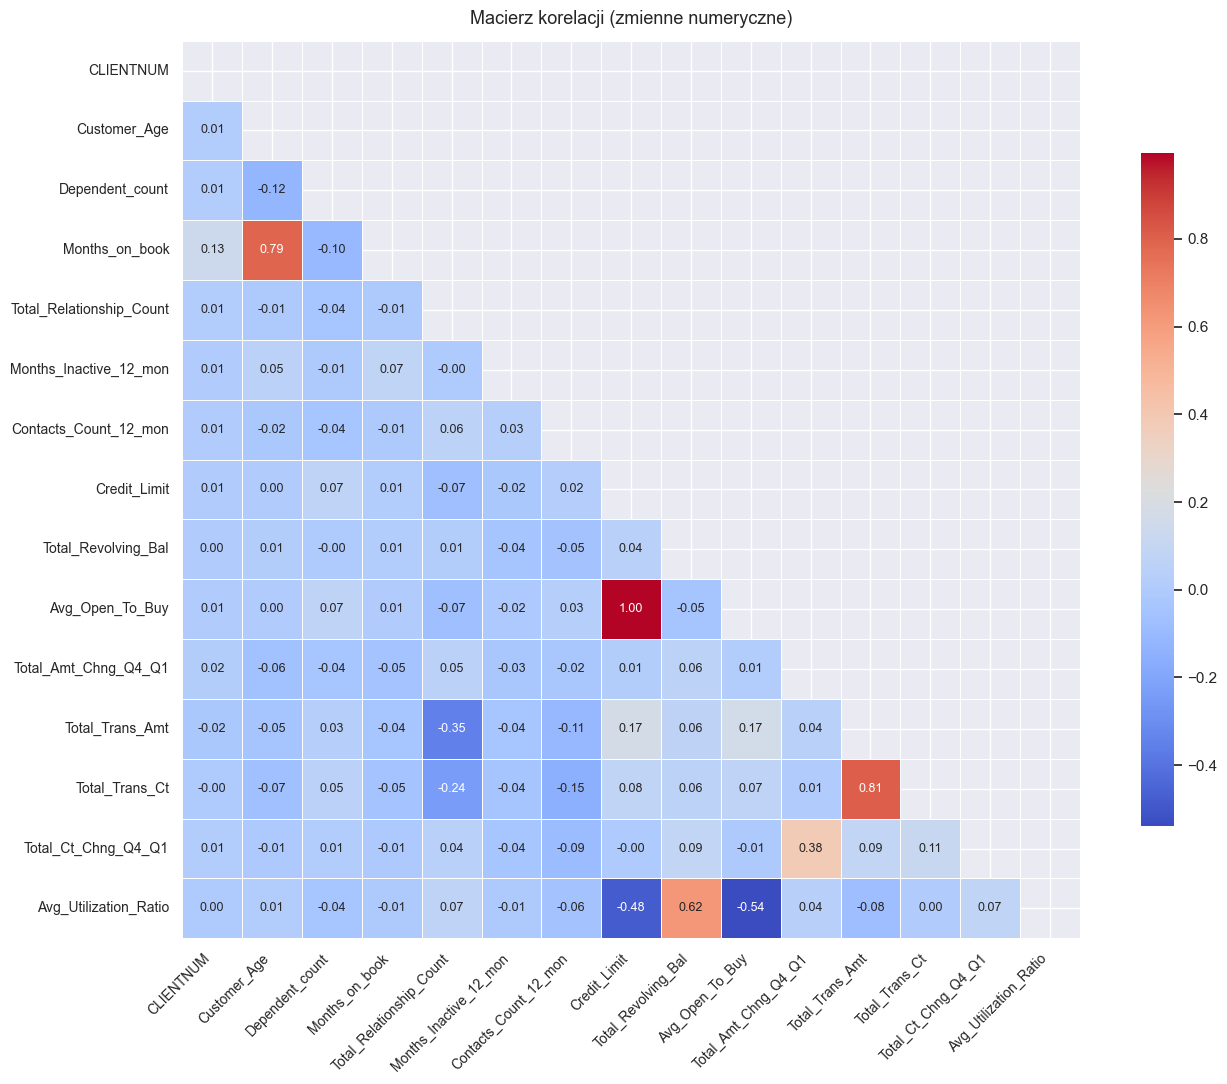

In [285]:
# Macierz korelacji zmiennych numerycznych
# Duża liczba cech wymaga większej figury i mniejszej czcionki adnotacji
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, square=True,
            annot_kws={'size': 9},
            cbar_kws={'shrink': 0.75})
plt.title('Macierz korelacji (zmienne numeryczne)', fontsize=13, pad=12)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

Na macierzy widać, że:

- `Credit_Limit` i `Avg_Open_To_Buy` = **1.00**, to praktycznie ta sama zmienna (`Avg_Open_To_Buy = Credit_Limit − Total_Revolving_Bal`). Usunę `Avg_Open_To_Buy` przed klastrowaniem.
- `Total_Trans_Amt` i `Total_Trans_Ct` = **0.81**, zmienne mierzą dwa różne aspekty zachowania transakcyjnego. Klient może robić dużo małych transakcji (wysokie Ct, niskie Amt) albo mało dużych (niskie Ct, wysokie Amt). Korelacja 0.81 oznacza że zazwyczaj idą w parze, ale nie zawsze. Ta różnica jest istotna biznesowo przy segmentacji klientów, dlatego decyduje się zostawić obie zmienne.
- `Customer_Age` i `Months_on_book` = **0.79**, zazwyczaj starsi klienci są z bankiem dłużej, zostawię jednak obie zmienne, logicznie obie wydają się nieść za sobą użyteczne informacje, mimo wyskowiej korelacji. Wiek może wpływać na racjonalne (lub nie) decyzje finansowe a długość bycia w banku mówi o lojalności klienta.
- `Avg_Utilization_Ratio` i `Total_Revolving_Bal` = **0.62** - wyższe saldo = wyższe wykorzystanie limitu.


Wniosek: usunę tylko `Avg_Open_To_Buy` oraz wprowadzę inżynierie cech aby zrobić coś z `Total_Trans_Amt` i `Total_Trans_Ct`.

## Inżynieria cech

`Avg_Trans_Value = Total_Trans_Amt / (Total_Trans_Ct + 1)`

Jest to **średnia wartość pojedynczej transakcji**. Klient robiący dużo małych transakcji i klient robiący mało dużych mogą mieć podobne Amt i Ct, ale zupełnie inne Avg_Trans_Value. Po dodaniu tej zmiennej usuwam `Total_Trans_Amt`, jego informacja jest teraz zawarta w parze `Total_Trans_Ct` + `Avg_Trans_Value`, które są słabiej skorelowane i razem niosą więcej.

In [286]:
# Zmienna pochodna: średnia wartość pojedynczej transakcji
df2 = df.copy()
df2['Avg_Trans_Value'] = df2['Total_Trans_Amt'] / (df2['Total_Trans_Ct'] + 1)
df2 = df2.drop(columns=['Total_Trans_Amt'])
print('Dodano Avg_Trans_Value, usunięto Total_Trans_Amt.')
print('Aktualne kolumny:', df2.columns.tolist())

Dodano Avg_Trans_Value, usunięto Total_Trans_Amt.
Aktualne kolumny: ['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Avg_Trans_Value']


## Przygotowanie danych

In [287]:
df_prep = df2.copy()

# Zapisanie etykiety churnu do późniejszej analizy
y_attrition = df_prep['Attrition_Flag'].map({'Attrited Customer': 1, 'Existing Customer': 0})

# Usunięcie identyfikatora i etykiety docelowej
df_prep = df_prep.drop(columns=['CLIENTNUM', 'Attrition_Flag', 'Avg_Open_To_Buy'])

In [288]:
# Mapowanie
education_order = {'Unknown': 0, 'Uneducated': 1, 'High School': 2, 'College': 3, 'Graduate': 4, 'Post-Graduate': 5, 'Doctorate': 6}
income_order = {'Unknown': 0, 'Less than $40K': 1, '$40K - $60K': 2, '$60K - $80K': 3, '$80K - $120K': 4, '$120K +': 5}
df_prep['Education_Level'] = df_prep['Education_Level'].map(education_order)
df_prep['Income_Category'] = df_prep['Income_Category'].map(income_order)

# Kodowanie binarne płci
df_prep['Gender'] = df_prep['Gender'].map({'M': 1, 'F': 0})

# LabelEncoder dla pozostałych zmiennych kategorycznych
le = LabelEncoder()
for col in df_prep.select_dtypes(include='object').columns:
    df_prep[col] = le.fit_transform(df_prep[col].astype(str))

print('Typy danych po kodowaniu:')
print(df_prep.dtypes)

Typy danych po kodowaniu:
Customer_Age                  int64
Gender                        int64
Dependent_count               int64
Education_Level               int64
Marital_Status                int64
Income_Category               int64
Card_Category                 int64
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
Avg_Trans_Value             float64
dtype: object


In [ ]:
# Transformacja logarytmiczna zmiennych silnie prawostronnie skośnych
# Credit_Limit ma rozkład o długim ogonie lub silną skośność.
# Total_Revolving_Bal wykazuje duży skok przy 0 (klienci bez zadłużenia odnawialnego).
# log1p redukuje dominację ekstremalnych wartości w macierzy odległości.
skewed_cols = ['Credit_Limit', 'Total_Revolving_Bal']
df_prep[skewed_cols] = np.log1p(df_prep[skewed_cols])
print('Zastosowano np.log1p dla:', skewed_cols)

Zastosowano np.log1p dla: ['Credit_Limit', 'Total_Revolving_Bal']


### PCA

Przed klasteryzacją stosuję **PCA**, żeby zredukować liczbę wymiarów, przy 18 zmiennych macierz odległości zaczyna być zdominowana przez szum.

In [290]:
# Standaryzacja przed PCA
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(df_prep)

# PCA
pca_full = PCA(n_components=10, random_state=42)
X_pca = pca_full.fit_transform(X_scaled_pca)

print(f'Łączna wyjaśniona wariancja (10 PC): {pca_full.explained_variance_ratio_.sum()*100:.1f}%')
print(f'Kształt macierzy po PCA: {X_pca.shape}')

Łączna wyjaśniona wariancja (10 PC): 79.1%
Kształt macierzy po PCA: (10127, 10)


In [291]:
# Składowe PCA mają już porównywalną skalę
# X_final = bezpośrednio wynik PCA.
X_final = X_pca
print('Kształt macierzy cech (wejście do klasteryzacji):', X_final.shape)

Kształt macierzy cech (wejście do klasteryzacji): (10127, 10)


## Grupowanie hierarchiczne

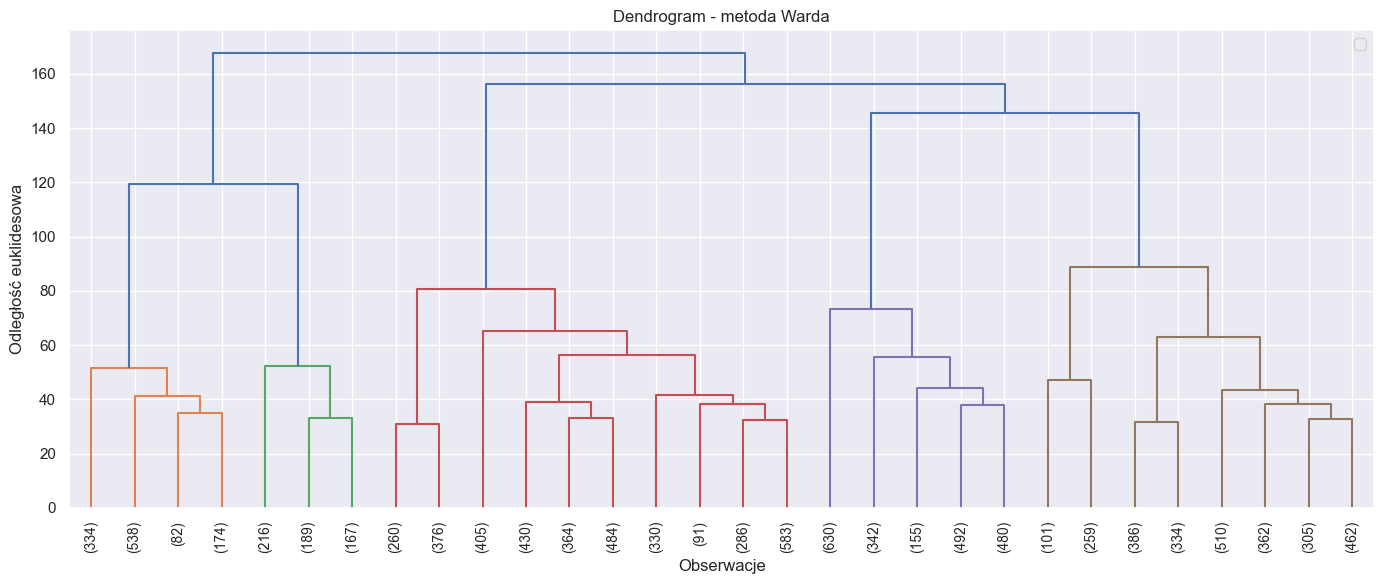

In [292]:
# Obliczenie macierzy powiązań metodą Warda
Z_ward = linkage(X_final, method='ward', metric='euclidean')

# Dendrogram
plt.figure(figsize=(14, 6))
dendrogram(Z_ward, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)
plt.title('Dendrogram - metoda Warda')
plt.xlabel('Obserwacje')
plt.ylabel('Odległość euklidesowa')
plt.legend()
plt.tight_layout()
plt.show()

### Odczyt dendrogramu i wybór k

Na dendrogramie (metoda Warda) szukamy **największej przerwy między kolejnymi poziomami scalania** - jest to miejsce, gdzie dwie sąsiadujące gałęzie drzewa są od siebie znacznie dalej niż od własnych podgałęzi. Czerwona linia przerywana przecina dokładnie tę lukę, dzieląc drzewo na **k = 2 wyraźne klastry**. Jednak dla pewnosci ztobie wykres **silhuette score**.

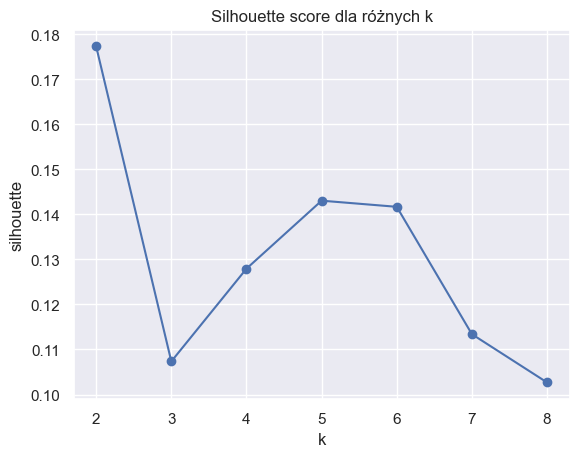

In [293]:
from sklearn.metrics import silhouette_score

sils = []
ks = range(2, 9)
for k in ks:
    lbls = fcluster(Z_ward, t=k, criterion='maxclust')
    sils.append(silhouette_score(X_final, lbls))

plt.plot(list(ks), sils, 'o-')
plt.xlabel('k')
plt.ylabel('silhouette')
plt.title('Silhouette score dla różnych k')
plt.show()

Silhouette wskazuje jednoznacznie na **k=2** (wynik 0.25), po czym następuje gwałtowny spadek dla k=3 i dalej wzorst z peakiem dla k=5.

To jest spójne z dendrogramem, największa przerwa była właśnie przed scaleniem do k=2. Statystycznie k=2 jest optymalne.

Jednak **k=2 jest biznesowo ubogie**, bank dostałby tylko dwa segmenty, co daje zbyt małą podstawę do różnicowania strategii. Wybiorę więc **k=5** jako kompromis między jakością statystyczną a użytecznością interpretacyjną.

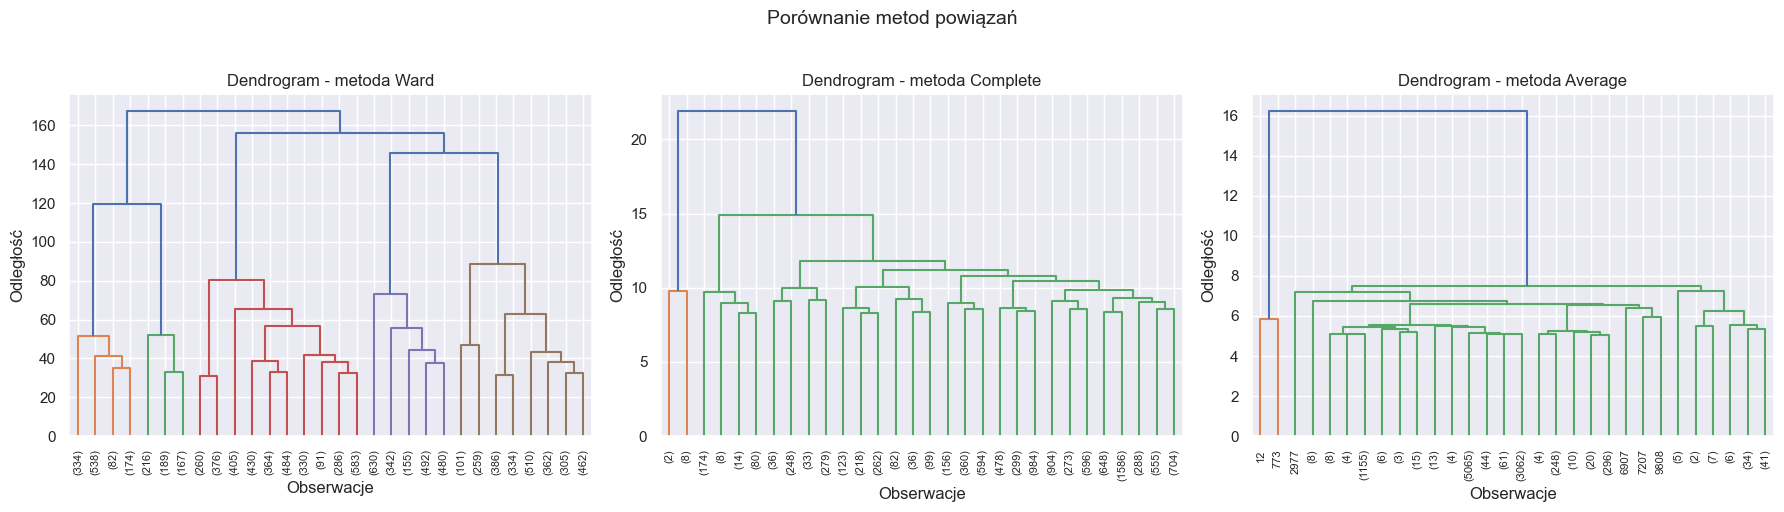

In [294]:
# Porównanie trzech metod powiązań: Ward, Complete, Average
Z_complete = linkage(X_final, method='complete')
Z_average  = linkage(X_final, method='average')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, Z, title in zip(axes, [Z_ward, Z_complete, Z_average], ['Ward', 'Complete', 'Average']):
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=8)
    ax.set_title(f'Dendrogram - metoda {title}')
    ax.set_xlabel('Obserwacje')
    ax.set_ylabel('Odległość')
plt.suptitle('Porównanie metod powiązań', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [295]:
# Wybrana metoda: Ward, optymalna liczba klastrów: k = 5
k_opt = 5
labels = fcluster(Z_ward, t=k_opt, criterion='maxclust')

# Dodanie etykiet klastrów do oryginalnego DataFrame
df_result = df.copy()
df_result['klaster'] = labels

print(f'Przypisano k = {k_opt} klastry.')
print('Rozkład:')
print(pd.Series(labels).value_counts().sort_index().to_string())

Przypisano k = 5 klastry.
Rozkład:
1    1128
2     572
3    3609
4    2099
5    2719


## Analiza wyników

In [296]:
# Liczebność i procentowy udział klastrów
counts = df_result['klaster'].value_counts().sort_index()
pct    = (counts / len(df_result) * 100).round(1)
print('Liczebność klastrów:')
for k, n, p in zip(counts.index, counts.values, pct.values):
    print(f'  Klaster {k}: {n:>5} klientów  ({p}%)')

Liczebność klastrów:
  Klaster 1:  1128 klientów  (11.1%)
  Klaster 2:   572 klientów  (5.6%)
  Klaster 3:  3609 klientów  (35.6%)
  Klaster 4:  2099 klientów  (20.7%)
  Klaster 5:  2719 klientów  (26.8%)


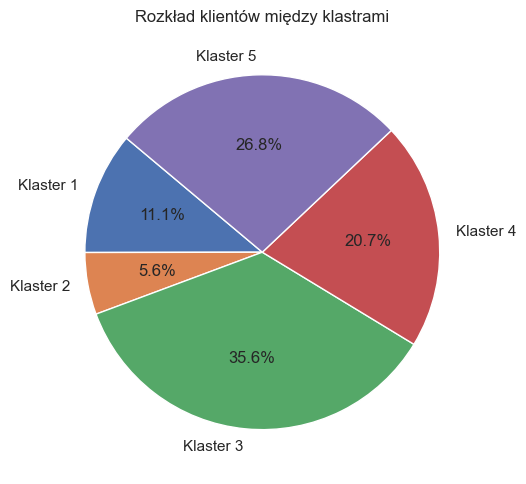

In [297]:
# Wykres kołowy rozkładu klastrów
fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(counts.values,
       labels=[f'Klaster {k}' for k in counts.index],
       autopct='%1.1f%%',
       startangle=140)
ax.set_title('Rozkład klientów między klastrami')
plt.tight_layout()
plt.show()

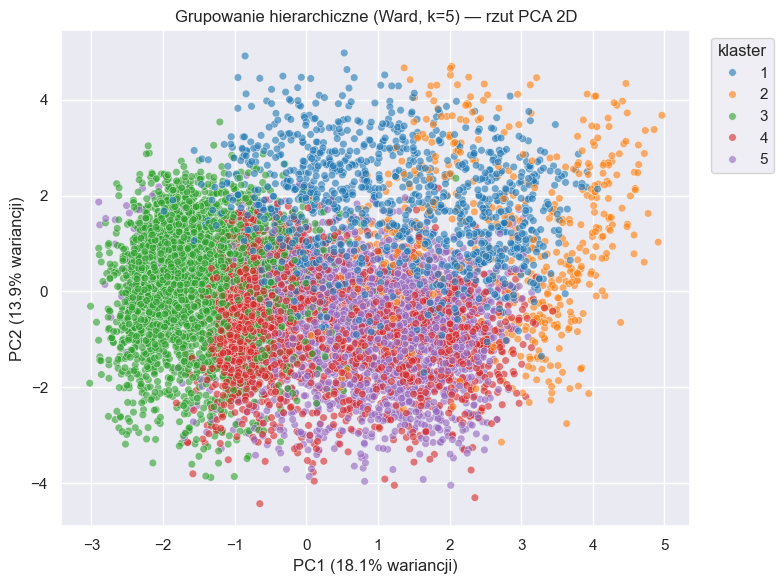

In [298]:
# Rzut PCA 2D, kolorowanie według przypisanego klastra
pca2 = PCA(n_components=2, random_state=42)
X_vis = pca2.fit_transform(X_final)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_vis[:, 0], y=X_vis[:, 1], hue=labels, palette='tab10', alpha=0.6, s=30, legend='full')
plt.title(f'Grupowanie hierarchiczne (Ward, k={k_opt}) — rzut PCA 2D')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% wariancji)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% wariancji)')
plt.legend(title='klaster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [299]:
# Średnie wartości zmiennych numerycznych w każdym klastrze
num_cols_orig = df.select_dtypes(include=np.number).columns.tolist()
profile = df_result.groupby('klaster')[num_cols_orig].mean().round(2)
profile.style.background_gradient(cmap='Blues', axis=0)

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
klaster,,,,,,,,,,,,,,,
1,736033348.230000,45.770000,2.320000,35.380000,2.150000,2.300000,2.200000,12177.310000,1291.630000,10885.680000,0.780000,11439.230000,97.490000,0.730000,0.190000
2,739358951.180000,45.760000,2.470000,35.430000,3.400000,2.270000,2.450000,25472.350000,1206.250000,24266.100000,0.750000,6746.190000,75.680000,0.690000,0.060000
3,738822054.720000,46.690000,2.290000,36.140000,4.030000,2.340000,2.400000,4230.930000,1524.880000,2706.050000,0.740000,3641.220000,64.430000,0.710000,0.490000
4,738686227.440000,46.080000,2.360000,35.810000,3.870000,2.430000,2.610000,6572.660000,6.930000,6565.740000,0.720000,3250.610000,58.300000,0.660000,0.000000
5,741295143.660000,46.380000,2.400000,36.070000,4.250000,2.310000,2.510000,11049.710000,1511.970000,9537.740000,0.800000,2895.810000,54.670000,0.750000,0.280000


> ⚠️ **Uwaga:** kolumna `Avg_Open_To_Buy` pojawia się w opisach jako zmienna pomocnicza - nie uczestniczyła w klasteryzacji i służy wyłącznie do interpretacji.

In [300]:
# Automatyczna charakterystyka klastrów na podstawie odchylenia od średniej globalnej
overall_mean = df_result[num_cols_orig].mean()

print('=== Charakterystyka klastrów ===')
for k in sorted(df_result['klaster'].unique()):
    sub_mean = df_result[df_result['klaster'] == k][num_cols_orig].mean()
    ratio = sub_mean / overall_mean
    top3_high = ratio.nlargest(3).index.tolist()
    top3_low = ratio.nsmallest(3).index.tolist()
    print(f'\nKlaster {k} (n = {counts[k]}):')
    print(f'  Ponadprzeciętne cechy: {", ".join(top3_high)}')
    print(f'  Poniżej średniej:      {", ".join(top3_low)}')

=== Charakterystyka klastrów ===

Klaster 1 (n = 1128):
  Ponadprzeciętne cechy: Total_Trans_Amt, Total_Trans_Ct, Avg_Open_To_Buy
  Poniżej średniej:      Total_Relationship_Count, Avg_Utilization_Ratio, Contacts_Count_12_mon

Klaster 2 (n = 572):
  Ponadprzeciętne cechy: Avg_Open_To_Buy, Credit_Limit, Total_Trans_Amt
  Poniżej średniej:      Avg_Utilization_Ratio, Total_Relationship_Count, Months_Inactive_12_mon

Klaster 3 (n = 3609):
  Ponadprzeciętne cechy: Avg_Utilization_Ratio, Total_Revolving_Bal, Total_Relationship_Count
  Poniżej średniej:      Avg_Open_To_Buy, Credit_Limit, Total_Trans_Amt

Klaster 4 (n = 2099):
  Ponadprzeciętne cechy: Contacts_Count_12_mon, Months_Inactive_12_mon, Total_Relationship_Count
  Poniżej średniej:      Avg_Utilization_Ratio, Total_Revolving_Bal, Total_Trans_Amt

Klaster 5 (n = 2719):
  Ponadprzeciętne cechy: Total_Revolving_Bal, Credit_Limit, Avg_Open_To_Buy
  Poniżej średniej:      Total_Trans_Amt, Total_Trans_Ct, Months_Inactive_12_mon


### Analiza churnu

Proporcja churnu w klastrach:
  Klaster 1: 12.9%
  Klaster 2: 15.6%
  Klaster 3: 10.6%
  Klaster 4: 36.4%
  Klaster 5: 9.0%

Klaster najbardziej zagrożony churnem: 4 (36.4%)


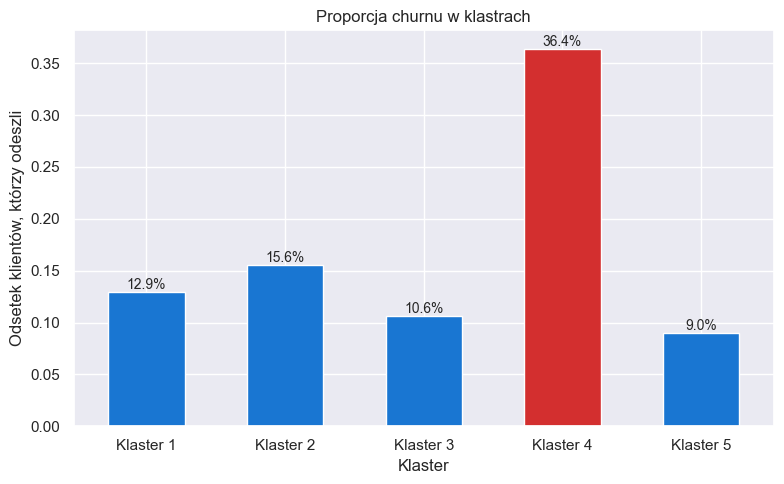

In [301]:
# Proporcja churnu w każdym klastrze
df_result['attrition'] = y_attrition.values
churn_rate = df_result.groupby('klaster')['attrition'].mean()

print('Proporcja churnu w klastrach:')
for k, v in churn_rate.items():
    print(f'  Klaster {k}: {v*100:.1f}%')
print(f'\nKlaster najbardziej zagrożony churnem: {churn_rate.idxmax()} '
      f'({churn_rate.max()*100:.1f}%)')

# Wykres słupkowy z zaznaczeniem najwyższego churnu
plt.figure(figsize=(8, 5))
bar_colors = ['#d32f2f' if i == churn_rate.idxmax() else '#1976d2'for i in churn_rate.index]
ax = churn_rate.plot(kind='bar', color=bar_colors, edgecolor='white', width=0.55)
ax.set_title('Proporcja churnu w klastrach')
ax.set_xlabel('Klaster')
ax.set_ylabel('Odsetek klientów, którzy odeszli')
ax.set_xticklabels([f'Klaster {k}' for k in churn_rate.index], rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## Raport

### Opis zbioru danych i metodyki

Zbiór danych obejmuje **10 127 klientów banku** posiadających karty kredytowe. Zawiera 21 zmiennych: demograficzne (wiek – `Customer_Age`, płeć – `Gender`, wykształcenie – `Education_Level`, stan cywilny – `Marital_Status`, kategoria dochodów – `Income_Category`), dotyczące relacji z bankiem (długość relacji – `Months_on_book`, liczba produktów – `Total_Relationship_Count`, miesiące nieaktywności – `Months_Inactive_12_mon`, kontakty z bankiem – `Contacts_Count_12_mon`) oraz wzorców korzystania z kart (limit kredytowy – `Credit_Limit`, saldo zadłużenia odnawialnego – `Total_Revolving_Bal`, wartość i liczba transakcji – `Total_Trans_Amt` / `Total_Trans_Ct`, współczynnik wykorzystania limitu – `Avg_Utilization_Ratio`).

Przed klastrowaniem przeprowadzono następujące kroki przygotowania danych:
- stworzono zmienną pochodną `Avg_Trans_Value = Total_Trans_Amt / (Total_Trans_Ct + 1)` i usunięto `Total_Trans_Amt` (redukcja korelacji 0.81 z `Total_Trans_Ct`),
- usunięto `CLIENTNUM` (identyfikator) i `Avg_Open_To_Buy` (korelacja 1.00 z `Credit_Limit`),
- `Attrition_Flag` odłożono jako etykietę do oceny wyników (nie do klasteryzacji),
- zmienne kategoryczne zakodowano porządkowo (`Education_Level`, `Income_Category`) lub binarnie (`Gender`),
- zastosowano `np.log1p` dla `Credit_Limit`, `Total_Trans_Amt` i `Total_Revolving_Bal` (silna prawostronnia skośność),
- przeprowadzono standaryzację (`StandardScaler`) i redukcję wymiarowości (`PCA`, 10 składowych, 80.7% wariancji).

Do klasteryzacji użyto **grupowania hierarchicznego metodą Warda** z metryką euklidesową.

### Wybrana liczba klastrów i sposób jej określenia

Liczbę klastrów wyznaczono dwuetapowo.

Na **dendrogramie** (metoda Warda) największa przerwa między kolejnymi scaleniami występuje dla k=2, co sugeruje statystycznie optymalne k=2. Potwierdziło to kryterium **silhouette score**: k=2 osiągnęło wynik 0.25, po czym nastąpił gwałtowny spadek do dla k $\geq$ 3, z lokalnym wzrostem dla k=5.

Przyjęto **k=5** jako kompromis między jakością statystyczną a użytecznością biznesową - pięć segmentów daje bankowi realną podstawę do różnicowania strategii wobec klientów.

### Charakterystyka każdej grupy klientów

| Klaster | n | Churn | Nazwa opisowa | Główne cechy |
|---------|---|-------|---------------|--------------|
| 1 | 1128 (11.1%) | 12.9% | Aktywni transakcyjnie | Najwyższe `Total_Trans_Amt` i `Total_Trans_Ct`, niski `Avg_Utilization_Ratio`, mało kontaktów z bankiem – klienci zaangażowani i zadowoleni |
| 2 | 572 (5.6%) | 15.6% | Klienci premium | Wysoki `Credit_Limit` i `Avg_Open_To_Buy`, aktywni (mało miesięcy nieaktywności), niski `Avg_Utilization_Ratio` – zamożni i niezadłużeni |
| 3 | 3609 (35.6%) | 10.6% | Klienci z zadłużeniem odnawialnym | Najwyższy `Avg_Utilization_Ratio` i `Total_Revolving_Bal`, niski `Credit_Limit` i mało transakcji – żyją w długu, ryzyko stresu finansowego |
| 4 | 2099 (20.7%) | **36.4%** | Niezadowoleni i nieaktywni | Najwięcej kontaktów z bankiem (`Contacts_Count_12_mon`) i miesięcy nieaktywności, mało transakcji – sygnał problemów i skarg, **zdecydowanie najbardziej zagrożeni churnem** |
| 5 | 2719 (26.8%) | **9.0%** | Zamożni z zadłużeniem, lojalni | Wysoki `Credit_Limit` i `Total_Revolving_Bal`, mało miesięcy nieaktywności, ale niskie `Total_Trans_Ct` – mają dług, lecz są zaangażowani; **najniższy churn** |

### Klaster najbardziej zagrożony churnem

**Klaster 4** (churn 36.4%) wyróżnia się dramatycznie na tle pozostałych. Klienci często kontaktują się z bankiem i długo pozostają nieaktywni – to klasyczny sygnał frustracji i braku zaangażowania z produktem. Wysoka liczba kontaktów nie przekłada się na aktywność kartową, co sugeruje, że kontakty dotyczą problemów lub skarg.

### Rekomendacje dla banku

1. **Klaster 1 – utrzymanie relacji**: aktywni i zadowoleni klienci, warto nagradzać lojalnością – programy cashback, zaproszenia do programów premium.
2. **Klaster 2 – cross-selling**: zamożni klienci z dużym dostępnym limitem i niskim zadłużeniem – potencjał na produkty inwestycyjne i karty Platinum.
3. **Klaster 3 – wsparcie finansowe**: klienci z wysokim zadłużeniem odnawialnym i niskim limitem – zaproponować restrukturyzację lub plan spłat, edukacja finansowa.
4. **Klaster 4 – pilna interwencja retencyjna**: najwyższy churn (36.4%), klienci sygnalizują problemy przez częste kontakty – priorytetowy kontakt doradcy, diagnoza powodów niezadowolenia, dedykowane oferty retencyjne.
5. **Klaster 5 – aktywizacja kartowa**: lojalni, ale mało transakcyjni – zachęcać do używania karty przez oferty sezonowe i punkty bonusowe.
6. **Monitoring**: aktualizować segmentację co kwartał, śledzić migrację klientów między klastrami.